# Runs all QM7 experiments with the full dataset!

Need to set up the weird stratified method...

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

In [255]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM7"
test_file='qm7.csv'
data_file_name='qm7_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")

TensorFlow version: 2.3.0
DeepChem version: 2.5.0


In [256]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge

In [257]:
hdf5_file_name='qm7_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	6838
num_of_molecules is:	 128
MolID: count
Counter({127: 6711, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [258]:
sum([1 for x in fh['molID'][:] if x == 127])

6711

In [259]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'u0_atom', 'u0_atom_norm', 'wasser_1', 'wasser_2', 'wasser_3']>

In [260]:
fh['u0_atom'][:]

array([ -417.96,  -712.42,  -564.21, ..., -1523.  , -1778.6 , -1531.9 ],
      dtype=float32)

In [261]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['u0_atom']

In [262]:
    data = []
    d1 = fh[feature_name_list[0]]
    d2 = fh[feature_name_list[1]]
    for i in range(len(d1)):
        if d1[i] > 0:
            data.append(d2[i])

In [263]:
X_data = np.zeros((num_of_rows,len(column_list)))

In [264]:
#fh.close()

In [265]:
X_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [266]:
def load_all_hdf5(fh,
                  num_of_rows, 
                  column_headers):
    """If dataset is small enough, load it all into memory
    fh = file handle
    num_of_rows = number of rows of data (i.e. molecules)
    column_headers into the hdf5 file"""
    data = np.zeros((num_of_rows,len(column_headers)))
    for key_num in range(len(column_headers)):
        key = column_headers[key_num]
        #print(key_num)
        d=fh[key]
        data[:,key_num] = d
    return data

X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = fh['SMILES']

In [267]:
SMILES_list[-1]

'[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'

In [268]:
print(len(X_data))
X_data

6838


array([[ 0.54585034, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.9279604 , -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.92463374, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.92778277, -0.        , -1.        , ..., 18.44346619,
         0.        ,  0.        ],
       [ 0.92784047,  3.14154887, -1.        , ..., 19.79535103,
         2.07662344,  0.        ],
       [ 0.92851228, -0.        , -1.        , ..., 20.98225403,
         0.        ,  0.        ]])

In [269]:
print(len(y_data))
y_data

6838


array([[ -417.95999146],
       [ -712.41998291],
       [ -564.21002197],
       ...,
       [-1523.        ],
       [-1778.59997559],
       [-1531.90002441]])

(array([  98.,  549., 1324., 2111., 1775.,  768.,  167.,   34.,    9.,
           3.]),
 array([-2192.        , -2013.28800049, -1834.57600098, -1655.86400146,
        -1477.15200195, -1298.44000244, -1119.72800293,  -941.01600342,
         -762.30400391,  -583.59200439,  -404.88000488]),
 <BarContainer object of 10 artists>)

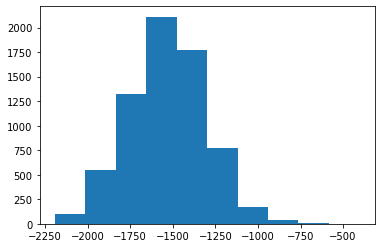

In [270]:
plt.hist(y_data)

In [271]:
# y been normalise here
#X_data = topol_feat_mat
#y_data = pd.DataFrame(my_starting_dataset.y, columns=tasks)
my_topol_data = dc.data.NumpyDataset(X=X_data, y=y_data, ids=SMILES_list)
print(my_topol_data)
#len(y_data)
#y_data.head()
topol_dataset = dc.data.DiskDataset.from_numpy(my_topol_data)

my_PCA_data = dc.data.NumpyDataset(X=PCA_X_data, y=y_data, ids=SMILES_list)
PCA_dataset = dc.data.DiskDataset.from_numpy(my_PCA_data)
PCA_dataset = dc.data.DiskDataset.from_numpy(PCA_X_data, y_data, ids=SMILES_list)

<NumpyDataset X.shape: (6838, 18), y.shape: (6838, 1), w.shape: (6838, 1), task_names: [0]>


In [238]:
topol_dataset = dc.data.DiskDataset.from_numpy(X_data, y_data, ids=SMILES_list)

In [272]:
topol_dataset.ids

array([0, 1, 2, ..., 6835, 6836, 6837], dtype=object)

In [273]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = datasets
len(train_dataset_ECFP) + len(valid_dataset_ECFP) + len(test_dataset_ECFP)

6838

In [148]:
test_dataset_ECFP.y[-1]

array([-1.16190034])

In [149]:
train_dataset_ECFP.ids[-1]

'[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'

In [150]:
#tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
#    shard_size=2000, featurizer="ECFP", splitter="stratified")
#_, _, small_dataset = datasets
## we're jsut going to use the test dataset here to test the code
#splitter = dc.splits.RandomSplitter()
#train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = splitter.train_valid_test_split(
#  dataset=small_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
#)

# We want to know the RMS, averaged across tasks
#avg_rms = dc.metrics.Metric(dc.metrics.mae_score)

In [235]:
PCA_dataset.ids

array(['[H].[H].[H][C][H]', '[H]C([H])([H])C([H])([H])[H]',
       '[H]C([H])=C([H])[H]', ...,
       '[H]/C(=C(\\C#N)C([H])([H])C([H])([H])[H])C([H])([H])[H]',
       '[H]C([H])=C1C([H])([H])C([H])=C([H])[C@]1([H])C([H])([H])[H]',
       '[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'],
      dtype=object)

In [274]:
Splitter_Object = dc.splits.SingletaskStratifiedSplitter()
train_dataset_tf, valid_dataset_tf, test_dataset_tf = Splitter_Object.train_valid_test_split(
    dataset=topol_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)

Splitter_Object_PCA = dc.splits.SingletaskStratifiedSplitter()
train_dataset_pca, valid_dataset_pca, test_dataset_pca = Splitter_Object_PCA.train_valid_test_split(
    dataset=PCA_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)



ValueError: need at least one array to concatenate

In [182]:
train_dataset_tf.ids

array(['[H]c1sc([H])c2c1N([H])C2([H])[H]',
       '[H]OC([H])([H])c1snc([H])c1[H]', '[H]Oc1c(O[H])c([H])n([H])c1[H]',
       ..., '[H]OC([H])([H])C([H])([H])[H]', '[H]N1C([H])([H])C1([H])[H]',
       '[H][C]([H])[N]OC([H])([H])[H]'], dtype=object)

In [152]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])
print(my_untransformed_dataset.y[:5])
# y been normalise here
X_data_un = topol_feat_mat
y_data_un = pd.DataFrame(my_untransformed_dataset.y, columns=tasks)

NameError: name 'orig_test_dataset' is not defined

In [153]:
(train_scores,test_scores) = h.run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=10,
    validate_set_size=10)

out=h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')
(min_train_RF_large, mean_train_RF_large, std_error_train_RF_large, max_train_RF_large,
                min_test_RF_large, mean_test_RF_large, std_error_test_RF_large, max_test_RF_large)=out
RF_large_train_scores=train_scores
RF_large_test_scores=test_scores

C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed

ValueError: too many values to unpack (expected 2)

In [ ]:
h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')

In [ ]:
def run_repeated_keras_NN_tests_mae(
    X_data,
    y_data,
    keras_model=None,
    num_of_repeats=10,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1),
    metric1=dc.metrics.Metric(dc.metrics.pearson_r2_score),
    metric2 = dc.metrics.Metric(dc.metrics.mae_score)
    ):

    num_of_proteins = len(X_data)
    size_of_output = len(y_data.columns)

    train_scores_r2=[]
    test_scores_r2=[]
    train_scores_mae=[]
    test_scores_mae=[]

    for trial in range(num_of_repeats):
        (train_X_data, ###
         train_y_data,
         test_X_data,
         test_y_data,
         validate_X_data,
         validate_y_data) = h.set_up_train_test_validate(
            X_data,
            y_data,
            test_set_size=test_set_size,
            validate_set_size=validate_set_size,
            verbose=True)
        # put data into a dataset for input to keras
        train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
        test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
        # choose metric(s)
        metric1 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
        metric2 = dc.metrics.Metric(dc.metrics.mae_score)
        # make deepchem model from keras model
        if keras_model == None:
            keras_model = h.create_keras_model(size_of_output=size_of_output)
        model = dc.models.KerasModel(keras_model, dc.models.losses.L2Loss())
        # fit it
        model.fit(train_dataset, nb_epoch=num_of_epochs)
        train_score = model.evaluate(train_dataset, [metric1, metric2])
        test_score = model.evaluate(test_dataset, [metric1, metric2])
        train_score_r2 = train_score['pearson_r2_score']
        test_score_r2 = test_score['pearson_r2_score']
        train_score_mae = train_score['mae_score']
        test_score_mae = test_score['mae_score']
        print('R2 error\ttrain {:.3}, \t test: {:.3}'.format(train_score_r2, test_score_r2))
        print('MAE error\ttrain {:.3}, \t test: {:.3}'.format(train_score_mae, test_score_mae))
        train_scores_r2.append(train_score_r2)
        test_scores_r2.append(test_score_r2)
        train_scores_mae.append(train_score_mae)
        test_scores_mae.append(test_score_mae)

    print(train_scores_r2)
    print(test_scores_r2)
    out=(train_scores_r2, test_scores_r2, train_scores_mae, test_scores_mae, keras_model)
    return out

In [ ]:
keras_model = h.create_keras_model()
out=run_repeated_keras_NN_tests_mae(
    train_dataset_tf.X,
    train_dataset_tf.y,
    keras_model=keras_model,
    num_of_repeats=5,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1))

(train_scores_r2, \
 test_scores_r2, train_scores_rmse, \
 test_scores_rmse, trained_keras_model) = out

In [ ]:
my_topol_data.to_dataframe().head()

In [246]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_tf, validate_scores_tf, test_scores_tf = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_tf, 5, metric1)
    model.fit(train_dataset_tf, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_tf.append(model.evaluate(train_dataset_tf, 
                                       metric1)['mae_score'])
    validate_scores_tf.append(model.evaluate(valid_dataset_tf, 
                                          metric1)['mae_score'])
    test_scores_tf.append(model.evaluate(test_dataset_tf, 
                                      metric1)['mae_score'])

Step 5 validation: mae_score=482.848
Step 10 validation: mae_score=419.663
Step 15 validation: mae_score=315.264
Step 20 validation: mae_score=272.668
Step 25 validation: mae_score=238.55
Step 30 validation: mae_score=470.154
Step 35 validation: mae_score=181.939
Step 40 validation: mae_score=180.919
Step 45 validation: mae_score=217.62
Step 50 validation: mae_score=189.7
Step 55 validation: mae_score=212.738
Step 60 validation: mae_score=185.3
Step 65 validation: mae_score=179.472
Step 70 validation: mae_score=183.565
Step 75 validation: mae_score=182.213
Step 80 validation: mae_score=596.335
Step 85 validation: mae_score=396.378
Step 90 validation: mae_score=428.863
Step 95 validation: mae_score=282.715
Step 100 validation: mae_score=300.156
Step 105 validation: mae_score=218.332
Step 110 validation: mae_score=245.049
Step 115 validation: mae_score=182.464
Step 120 validation: mae_score=190.469
Step 125 validation: mae_score=180.399
Step 130 validation: mae_score=184.558
Step 135 val

Step 1065 validation: mae_score=187.998
Step 1070 validation: mae_score=180.317
Step 1075 validation: mae_score=182.794
Step 1080 validation: mae_score=203.574
Step 1085 validation: mae_score=181.883
Step 1090 validation: mae_score=179.412
Step 1095 validation: mae_score=184.726
Step 1100 validation: mae_score=176.768
Step 1105 validation: mae_score=182.076
Step 1110 validation: mae_score=184.286
Step 1115 validation: mae_score=175.734
Step 1120 validation: mae_score=178.362
Step 1125 validation: mae_score=176.281
Step 1130 validation: mae_score=179.272
Step 1135 validation: mae_score=181.641
Step 1140 validation: mae_score=183.655
Step 1145 validation: mae_score=179.631
Step 1150 validation: mae_score=178.536
Step 1155 validation: mae_score=176.138
Step 1160 validation: mae_score=185.826
Step 1165 validation: mae_score=176.94
Step 1170 validation: mae_score=182.574
Step 1175 validation: mae_score=177.114
Step 1180 validation: mae_score=180.907
Step 1185 validation: mae_score=186.266
S

Step 2100 validation: mae_score=187.308
Step 2105 validation: mae_score=185.728
Step 2110 validation: mae_score=207.775
Step 2115 validation: mae_score=179.678
Step 2120 validation: mae_score=202.421
Step 2125 validation: mae_score=174.769
Step 2130 validation: mae_score=182.093
Step 2135 validation: mae_score=175.202
Step 2140 validation: mae_score=185.514
Step 2145 validation: mae_score=174.058
Step 2150 validation: mae_score=174.738
Step 2155 validation: mae_score=184.144
Step 2160 validation: mae_score=174.139
Step 2165 validation: mae_score=187.723
Step 2170 validation: mae_score=176.128
Step 2175 validation: mae_score=184.129
Step 2180 validation: mae_score=176.977
Step 2185 validation: mae_score=174.12
Step 2190 validation: mae_score=175.905
Step 2195 validation: mae_score=182.166
Step 2200 validation: mae_score=174.437
Step 2205 validation: mae_score=188.32
Step 2210 validation: mae_score=174.225
Step 2215 validation: mae_score=176.394
Step 2220 validation: mae_score=178.526
St

Step 3130 validation: mae_score=175.769
Step 3135 validation: mae_score=182.144
Step 3140 validation: mae_score=178.324
Step 3145 validation: mae_score=184.967
Step 3150 validation: mae_score=178.006
Step 3155 validation: mae_score=187.656
Step 3160 validation: mae_score=177.207
Step 3165 validation: mae_score=185.114
Step 3170 validation: mae_score=185.393
Step 3175 validation: mae_score=179.097
Step 3180 validation: mae_score=179.741
Step 3185 validation: mae_score=179.14
Step 3190 validation: mae_score=175.667
Step 3195 validation: mae_score=193.824
Step 3200 validation: mae_score=175.504
Step 3205 validation: mae_score=179.954
Step 3210 validation: mae_score=178.819
Step 3215 validation: mae_score=187.62
Step 3220 validation: mae_score=179.848
Step 3225 validation: mae_score=185.933
Step 3230 validation: mae_score=175.084
Step 3235 validation: mae_score=181.064
Step 3240 validation: mae_score=177.839
Step 3245 validation: mae_score=187.083
Step 3250 validation: mae_score=175.915
St

Step 4170 validation: mae_score=174.497
Step 4175 validation: mae_score=176.621
Step 4180 validation: mae_score=175.165
Step 4185 validation: mae_score=173.502
Step 4190 validation: mae_score=174.155
Step 4195 validation: mae_score=174.055
Step 4200 validation: mae_score=173.559
Step 4205 validation: mae_score=186.871
Step 4210 validation: mae_score=173.593
Step 4215 validation: mae_score=181.12
Step 4220 validation: mae_score=177.334
Step 4225 validation: mae_score=196.206
Step 4230 validation: mae_score=173.327
Step 4235 validation: mae_score=183.643
Step 4240 validation: mae_score=177.456
Step 4245 validation: mae_score=175.626
Step 4250 validation: mae_score=184.261
Step 4255 validation: mae_score=174.376
Step 4260 validation: mae_score=178.218
Step 4265 validation: mae_score=173.501
Step 4270 validation: mae_score=176.684
Step 4275 validation: mae_score=172.646
Step 4280 validation: mae_score=176.22
Step 4285 validation: mae_score=172.982
Step 4290 validation: mae_score=173.94
Ste

...

Step 9320 validation: mae_score=206.903
Step 9325 validation: mae_score=190.993
Step 9330 validation: mae_score=176.817
Step 9335 validation: mae_score=204.286
Step 9340 validation: mae_score=176.917
Step 9345 validation: mae_score=191.304
Step 9350 validation: mae_score=172.428
Step 9355 validation: mae_score=176.346
Step 9360 validation: mae_score=293.934
Step 9365 validation: mae_score=184.882
Step 9370 validation: mae_score=236.97
Step 9375 validation: mae_score=189.363
Step 9380 validation: mae_score=183.817
Step 9385 validation: mae_score=214.876
Step 9390 validation: mae_score=330.18
Step 9395 validation: mae_score=196.856
Step 9400 validation: mae_score=211.359
Step 9405 validation: mae_score=313.238
Step 9410 validation: mae_score=200.896
Step 9415 validation: mae_score=230.33
Step 9420 validation: mae_score=240.161
Step 9425 validation: mae_score=213.824
Step 9430 validation: mae_score=203.295
Step 9435 validation: mae_score=193.047
Step 9440 validation: mae_score=214.375
Ste

Step 10340 validation: mae_score=186.212
Step 10345 validation: mae_score=191.878
Step 10350 validation: mae_score=184.226
Step 10355 validation: mae_score=174.609
Step 10360 validation: mae_score=213.071
Step 10365 validation: mae_score=186.34
Step 10370 validation: mae_score=181.182
Step 10375 validation: mae_score=204.463
Step 10380 validation: mae_score=179.446
Step 10385 validation: mae_score=190.593
Step 10390 validation: mae_score=189.419
Step 10395 validation: mae_score=175.169
Step 10400 validation: mae_score=240.089
Step 10405 validation: mae_score=177.907
Step 10410 validation: mae_score=198.279
Step 10415 validation: mae_score=174.534
Step 10420 validation: mae_score=204.155
Step 10425 validation: mae_score=192.329
Step 10430 validation: mae_score=174.363
Step 10435 validation: mae_score=220.527
Step 10440 validation: mae_score=173.624
Step 10445 validation: mae_score=224.169
Step 10450 validation: mae_score=194.282
Step 10455 validation: mae_score=175.472
Step 10460 valida

Step 11350 validation: mae_score=175.541
Step 11355 validation: mae_score=259.395
Step 11360 validation: mae_score=191.143
Step 11365 validation: mae_score=237.043
Step 11370 validation: mae_score=187.931
Step 11375 validation: mae_score=174.653
Step 11380 validation: mae_score=193.303
Step 11385 validation: mae_score=180.821
Step 11390 validation: mae_score=211.877
Step 11395 validation: mae_score=176.531
Step 11400 validation: mae_score=227.786
Step 11405 validation: mae_score=178.714
Step 11410 validation: mae_score=181.261
Step 11415 validation: mae_score=209.546
Step 11420 validation: mae_score=176.427
Step 11425 validation: mae_score=199.485
Step 11430 validation: mae_score=198.158
Step 11435 validation: mae_score=174.885
Step 11440 validation: mae_score=197.279
Step 11445 validation: mae_score=206.276
Step 11450 validation: mae_score=179.327
Step 11455 validation: mae_score=188.722
Step 11460 validation: mae_score=191.076
Step 11465 validation: mae_score=173.802
Step 11470 valid

Step 12365 validation: mae_score=189.021
Step 12370 validation: mae_score=181.145
Step 12375 validation: mae_score=178.977
Step 12380 validation: mae_score=205.051
Step 12385 validation: mae_score=173.826
Step 12390 validation: mae_score=186.512
Step 12395 validation: mae_score=194.121
Step 12400 validation: mae_score=184.329
Step 12405 validation: mae_score=209.387
Step 12410 validation: mae_score=173.309
Step 12415 validation: mae_score=203.096
Step 12420 validation: mae_score=192.799
Step 12425 validation: mae_score=176.735
Step 12430 validation: mae_score=202.197
Step 12435 validation: mae_score=178.252
Step 12440 validation: mae_score=174.604
Step 12445 validation: mae_score=211.114
Step 12450 validation: mae_score=171.998
Step 12455 validation: mae_score=193.917
Step 12460 validation: mae_score=211.045
Step 12465 validation: mae_score=174.49
Step 12470 validation: mae_score=210.698
Step 12475 validation: mae_score=174.835
Step 12480 validation: mae_score=186.294
Step 12485 valida

Step 13375 validation: mae_score=181.101
Step 13380 validation: mae_score=173.021
Step 13385 validation: mae_score=228.353
Step 13390 validation: mae_score=173.638
Step 13395 validation: mae_score=204.434
Step 13400 validation: mae_score=172.674
Step 13405 validation: mae_score=196.689
Step 13410 validation: mae_score=180.035
Step 13415 validation: mae_score=172.744
Step 13420 validation: mae_score=218.298
Step 13425 validation: mae_score=173.135
Step 13430 validation: mae_score=219.537
Step 13435 validation: mae_score=179.504
Step 13440 validation: mae_score=226.923
Step 13445 validation: mae_score=173.062
Step 13450 validation: mae_score=198.074
Step 13455 validation: mae_score=177.293
Step 13460 validation: mae_score=236.862
Step 13465 validation: mae_score=174.376
Step 13470 validation: mae_score=185.331
Step 13475 validation: mae_score=179.87
Step 13480 validation: mae_score=185.272
Step 13485 validation: mae_score=177.571
Step 13490 validation: mae_score=178.858
Step 13495 valida

In [254]:
test_scores_tf

[199.00143597939353]

In [247]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_pca, validate_scores_pca, test_scores_pca = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_pca, 5, metric1)
    model.fit(train_dataset_pca, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_pca.append(model.evaluate(train_dataset_pca, 
                                       metric1)['mae_score'])
    validate_scores_pca.append(model.evaluate(valid_dataset_pca,
                                          metric1)['mae_score'])
    test_scores_pca.append(model.evaluate(test_dataset_pca,
                                      metric1)['mae_score'])

Step 5 validation: mae_score=317.365
Step 10 validation: mae_score=357.825
Step 15 validation: mae_score=392.127
Step 20 validation: mae_score=589.101
Step 25 validation: mae_score=225.991
Step 30 validation: mae_score=253.936
Step 35 validation: mae_score=181.811
Step 40 validation: mae_score=210.871
Step 45 validation: mae_score=203.1
Step 50 validation: mae_score=177.006
Step 55 validation: mae_score=179.022
Step 60 validation: mae_score=182.814
Step 65 validation: mae_score=185.373
Step 70 validation: mae_score=242.914
Step 75 validation: mae_score=198.118
Step 80 validation: mae_score=229.602
Step 85 validation: mae_score=180.64
Step 90 validation: mae_score=246.953
Step 95 validation: mae_score=197.059
Step 100 validation: mae_score=182.233
Step 105 validation: mae_score=447.377
Step 110 validation: mae_score=360.118
Step 115 validation: mae_score=1035.14
Step 120 validation: mae_score=805.899
Step 125 validation: mae_score=195.39
Step 130 validation: mae_score=365.682
Step 135 v

Step 1060 validation: mae_score=186.738
Step 1065 validation: mae_score=188.672
Step 1070 validation: mae_score=187.488
Step 1075 validation: mae_score=184.205
Step 1080 validation: mae_score=185.321
Step 1085 validation: mae_score=186.707
Step 1090 validation: mae_score=188.837
Step 1095 validation: mae_score=188.041
Step 1100 validation: mae_score=188.46
Step 1105 validation: mae_score=188.578
Step 1110 validation: mae_score=188.531
Step 1115 validation: mae_score=186.564
Step 1120 validation: mae_score=185.918
Step 1125 validation: mae_score=190.465
Step 1130 validation: mae_score=207.847
Step 1135 validation: mae_score=205.237
Step 1140 validation: mae_score=188.434
Step 1145 validation: mae_score=184.02
Step 1150 validation: mae_score=183.526
Step 1155 validation: mae_score=190.576
Step 1160 validation: mae_score=188.719
Step 1165 validation: mae_score=183.955
Step 1170 validation: mae_score=183.213
Step 1175 validation: mae_score=191.252
Step 1180 validation: mae_score=194.827
St

Step 2095 validation: mae_score=179.725
Step 2100 validation: mae_score=180.913
Step 2105 validation: mae_score=181.135
Step 2110 validation: mae_score=179.106
Step 2115 validation: mae_score=178.08
Step 2120 validation: mae_score=181.294
Step 2125 validation: mae_score=179.529
Step 2130 validation: mae_score=179.427
Step 2135 validation: mae_score=179.866
Step 2140 validation: mae_score=178.294
Step 2145 validation: mae_score=179.2
Step 2150 validation: mae_score=199.354
Step 2155 validation: mae_score=181.014
Step 2160 validation: mae_score=182.022
Step 2165 validation: mae_score=178.01
Step 2170 validation: mae_score=187.91
Step 2175 validation: mae_score=179.012
Step 2180 validation: mae_score=178.312
Step 2185 validation: mae_score=195.667
Step 2190 validation: mae_score=204.691
Step 2195 validation: mae_score=182.427
Step 2200 validation: mae_score=183.617
Step 2205 validation: mae_score=181.154
Step 2210 validation: mae_score=190.11
Step 2215 validation: mae_score=189.939
Step 2

Step 3125 validation: mae_score=178.535
Step 3130 validation: mae_score=178.195
Step 3135 validation: mae_score=175.895
Step 3140 validation: mae_score=178.444
Step 3145 validation: mae_score=185.555
Step 3150 validation: mae_score=193.065
Step 3155 validation: mae_score=176.478
Step 3160 validation: mae_score=174.574
Step 3165 validation: mae_score=194.742
Step 3170 validation: mae_score=180.924
Step 3175 validation: mae_score=176.327
Step 3180 validation: mae_score=175.203
Step 3185 validation: mae_score=181.423
Step 3190 validation: mae_score=175.075
Step 3195 validation: mae_score=175.062
Step 3200 validation: mae_score=176.456
Step 3205 validation: mae_score=175.106
Step 3210 validation: mae_score=182.538
Step 3215 validation: mae_score=175.5
Step 3220 validation: mae_score=175.648
Step 3225 validation: mae_score=180.431
Step 3230 validation: mae_score=178.601
Step 3235 validation: mae_score=176.327
Step 3240 validation: mae_score=174.942
Step 3245 validation: mae_score=177.3
Step

Step 4155 validation: mae_score=185.555
Step 4160 validation: mae_score=174.446
Step 4165 validation: mae_score=172.744
Step 4170 validation: mae_score=178.17
Step 4175 validation: mae_score=175.915
Step 4180 validation: mae_score=180.277
Step 4185 validation: mae_score=172.825
Step 4190 validation: mae_score=174.239
Step 4195 validation: mae_score=190.406
Step 4200 validation: mae_score=176.736
Step 4205 validation: mae_score=173.715
Step 4210 validation: mae_score=181.904
Step 4215 validation: mae_score=172.019
Step 4220 validation: mae_score=200.008
Step 4225 validation: mae_score=173.112
Step 4230 validation: mae_score=173.397
Step 4235 validation: mae_score=180.612
Step 4240 validation: mae_score=172.884
Step 4245 validation: mae_score=175.286
Step 4250 validation: mae_score=193.24
Step 4255 validation: mae_score=181.794
Step 4260 validation: mae_score=177.159
Step 4265 validation: mae_score=179.347
Step 4270 validation: mae_score=173.623
Step 4275 validation: mae_score=180.795
St

...

Step 9330 validation: mae_score=183.777
Step 9335 validation: mae_score=181.493
Step 9340 validation: mae_score=183.887
Step 9345 validation: mae_score=174.405
Step 9350 validation: mae_score=184.966
Step 9355 validation: mae_score=181.778
Step 9360 validation: mae_score=173.915
Step 9365 validation: mae_score=185.657
Step 9370 validation: mae_score=195.167
Step 9375 validation: mae_score=173.691
Step 9380 validation: mae_score=175.027
Step 9385 validation: mae_score=179.544
Step 9390 validation: mae_score=177.21
Step 9395 validation: mae_score=177.904
Step 9400 validation: mae_score=185.471
Step 9405 validation: mae_score=175.163
Step 9410 validation: mae_score=174.358
Step 9415 validation: mae_score=196.631
Step 9420 validation: mae_score=180.108
Step 9425 validation: mae_score=172.924
Step 9430 validation: mae_score=188.965
Step 9435 validation: mae_score=186.282
Step 9440 validation: mae_score=172.026
Step 9445 validation: mae_score=179.091
Step 9450 validation: mae_score=201.046
S

Step 10360 validation: mae_score=184.672
Step 10365 validation: mae_score=218.77
Step 10370 validation: mae_score=174.319
Step 10375 validation: mae_score=181.772
Step 10380 validation: mae_score=182.93
Step 10385 validation: mae_score=174.163
Step 10390 validation: mae_score=172.091
Step 10395 validation: mae_score=177.045
Step 10400 validation: mae_score=176.097
Step 10405 validation: mae_score=178.3
Step 10410 validation: mae_score=179.82
Step 10415 validation: mae_score=173.438
Step 10420 validation: mae_score=173.139
Step 10425 validation: mae_score=191.576
Step 10430 validation: mae_score=175.578
Step 10435 validation: mae_score=176.593
Step 10440 validation: mae_score=194.781
Step 10445 validation: mae_score=172.095
Step 10450 validation: mae_score=173.668
Step 10455 validation: mae_score=196.315
Step 10460 validation: mae_score=176.153
Step 10465 validation: mae_score=174.869
Step 10470 validation: mae_score=197.977
Step 10475 validation: mae_score=173.88
Step 10480 validation:

Step 11375 validation: mae_score=177
Step 11380 validation: mae_score=187.04
Step 11385 validation: mae_score=187.516
Step 11390 validation: mae_score=188.838
Step 11395 validation: mae_score=197.418
Step 11400 validation: mae_score=196.77
Step 11405 validation: mae_score=184.44
Step 11410 validation: mae_score=183.644
Step 11415 validation: mae_score=185.945
Step 11420 validation: mae_score=184.756
Step 11425 validation: mae_score=193.391
Step 11430 validation: mae_score=196.227
Step 11435 validation: mae_score=182.951
Step 11440 validation: mae_score=181.962
Step 11445 validation: mae_score=181.859
Step 11450 validation: mae_score=190.661
Step 11455 validation: mae_score=180.725
Step 11460 validation: mae_score=180.946
Step 11465 validation: mae_score=188.178
Step 11470 validation: mae_score=185.509
Step 11475 validation: mae_score=181.356
Step 11480 validation: mae_score=174.766
Step 11485 validation: mae_score=184.102
Step 11490 validation: mae_score=196.44
Step 11495 validation: m

Step 12390 validation: mae_score=243.415
Step 12395 validation: mae_score=237.093
Step 12400 validation: mae_score=247.638
Step 12405 validation: mae_score=253.356
Step 12410 validation: mae_score=234.242
Step 12415 validation: mae_score=241.98
Step 12420 validation: mae_score=260.682
Step 12425 validation: mae_score=248.178
Step 12430 validation: mae_score=251.542
Step 12435 validation: mae_score=254.734
Step 12440 validation: mae_score=266.376
Step 12445 validation: mae_score=246.626
Step 12450 validation: mae_score=239.502
Step 12455 validation: mae_score=273.618
Step 12460 validation: mae_score=239.195
Step 12465 validation: mae_score=251.871
Step 12470 validation: mae_score=270.502
Step 12475 validation: mae_score=276.785
Step 12480 validation: mae_score=237.969
Step 12485 validation: mae_score=215.392
Step 12490 validation: mae_score=247.341
Step 12495 validation: mae_score=264.088
Step 12500 validation: mae_score=282.528
Step 12505 validation: mae_score=242.19
Step 12510 validat

Step 13395 validation: mae_score=213.874
Step 13400 validation: mae_score=226.025
Step 13405 validation: mae_score=430.237
Step 13410 validation: mae_score=505.023
Step 13415 validation: mae_score=302.204
Step 13420 validation: mae_score=206.95
Step 13425 validation: mae_score=288.765
Step 13430 validation: mae_score=367.445
Step 13435 validation: mae_score=327.824
Step 13440 validation: mae_score=256.337
Step 13445 validation: mae_score=233.634
Step 13450 validation: mae_score=218.278
Step 13455 validation: mae_score=255.355
Step 13460 validation: mae_score=279.603
Step 13465 validation: mae_score=253.584
Step 13470 validation: mae_score=229.769
Step 13475 validation: mae_score=219.234
Step 13480 validation: mae_score=232.836
Step 13485 validation: mae_score=260.53
Step 13490 validation: mae_score=248.471
Step 13495 validation: mae_score=218.952
Step 13500 validation: mae_score=205.41
Step 13505 validation: mae_score=208.966
Step 13510 validation: mae_score=237.958
Step 13515 validati

In [253]:
test_scores_pca

[229.6995756671509]

In [186]:
dc.models.DTNNTensorGraph

deepchem.models.graph_models.DTNNTensorGraph

## Controls

In [249]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ECFP, validate_scores_ECFP, test_scores_ECFP = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_ECFP.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ECFP.append(model.evaluate(valid_dataset_ECFP,
                                          metric1)['mae_score'])
    test_scores_ECFP.append(model.evaluate(test_dataset_ECFP,
                                      metric1)['mae_score'])

Step 5 validation: mae_score=1.18052
Step 10 validation: mae_score=1.19144
Step 15 validation: mae_score=1.19714
Step 20 validation: mae_score=1.20633
Step 25 validation: mae_score=1.25747
Step 30 validation: mae_score=1.1915
Step 35 validation: mae_score=0.932287
Step 40 validation: mae_score=0.829905
Step 45 validation: mae_score=0.799418
Step 50 validation: mae_score=0.804914
Step 55 validation: mae_score=0.776773
Step 60 validation: mae_score=0.792875
Step 65 validation: mae_score=0.785185
Step 70 validation: mae_score=0.78176
Step 75 validation: mae_score=0.772903
Step 80 validation: mae_score=0.772904
Step 85 validation: mae_score=0.775301
Step 90 validation: mae_score=0.78583
Step 95 validation: mae_score=0.788243
Step 100 validation: mae_score=0.784516
Step 105 validation: mae_score=0.777698
Step 110 validation: mae_score=0.788845
Step 115 validation: mae_score=0.800507
Step 120 validation: mae_score=0.80685
Step 125 validation: mae_score=0.779661
Step 130 validation: mae_score

Step 1040 validation: mae_score=0.850588
Step 1045 validation: mae_score=0.853068
Step 1050 validation: mae_score=0.84461
Step 1055 validation: mae_score=0.83902
Step 1060 validation: mae_score=0.836479
Step 1065 validation: mae_score=0.83464
Step 1070 validation: mae_score=0.839977
Step 1075 validation: mae_score=0.836501
Step 1080 validation: mae_score=0.852364
Step 1085 validation: mae_score=0.839739
Step 1090 validation: mae_score=0.840906
Step 1095 validation: mae_score=0.847234
Step 1100 validation: mae_score=0.83832
Step 1105 validation: mae_score=0.833006
Step 1110 validation: mae_score=0.828097
Step 1115 validation: mae_score=0.827975
Step 1120 validation: mae_score=0.832027
Step 1125 validation: mae_score=0.821867
Step 1130 validation: mae_score=0.840368
Step 1135 validation: mae_score=0.827032
Step 1140 validation: mae_score=0.827045
Step 1145 validation: mae_score=0.829222
Step 1150 validation: mae_score=0.823803
Step 1155 validation: mae_score=0.814652
Step 1160 validation

Step 2050 validation: mae_score=0.824717
Step 2055 validation: mae_score=0.82062
Step 2060 validation: mae_score=0.826631
Step 2065 validation: mae_score=0.832771
Step 2070 validation: mae_score=0.833617
Step 2075 validation: mae_score=0.836857
Step 2080 validation: mae_score=0.845296
Step 2085 validation: mae_score=0.836685
Step 2090 validation: mae_score=0.832309
Step 2095 validation: mae_score=0.837941
Step 2100 validation: mae_score=0.849657
Step 2105 validation: mae_score=0.832159
Step 2110 validation: mae_score=0.836159
Step 2115 validation: mae_score=0.829922
Step 2120 validation: mae_score=0.834467
Step 2125 validation: mae_score=0.838741
Step 2130 validation: mae_score=0.848389
Step 2135 validation: mae_score=0.841562
Step 2140 validation: mae_score=0.832037
Step 2145 validation: mae_score=0.837238
Step 2150 validation: mae_score=0.844711
Step 2155 validation: mae_score=0.852959
Step 2160 validation: mae_score=0.844505
Step 2165 validation: mae_score=0.853627
Step 2170 validat

Step 3050 validation: mae_score=0.838923
Step 3055 validation: mae_score=0.829372
Step 3060 validation: mae_score=0.829834
Step 3065 validation: mae_score=0.832209
Step 3070 validation: mae_score=0.845961
Step 3075 validation: mae_score=0.849354
Step 3080 validation: mae_score=0.84321
Step 3085 validation: mae_score=0.83973
Step 3090 validation: mae_score=0.835584
Step 3095 validation: mae_score=0.843939
Step 3100 validation: mae_score=0.843216
Step 3105 validation: mae_score=0.83909
Step 3110 validation: mae_score=0.842886
Step 3115 validation: mae_score=0.842892
Step 3120 validation: mae_score=0.854304
Step 3125 validation: mae_score=0.847854
Step 3130 validation: mae_score=0.837474
Step 3135 validation: mae_score=0.838093
Step 3140 validation: mae_score=0.846548
Step 3145 validation: mae_score=0.849934
Step 3150 validation: mae_score=0.835133
Step 3155 validation: mae_score=0.846206
Step 3160 validation: mae_score=0.849847
Step 3165 validation: mae_score=0.847275
Step 3170 validatio

Step 5060 validation: mae_score=0.847338
Step 5065 validation: mae_score=0.835169
Step 5070 validation: mae_score=0.816573
Step 5075 validation: mae_score=0.811459
Step 5080 validation: mae_score=0.823692
Step 5085 validation: mae_score=0.817013
Step 5090 validation: mae_score=0.821447
Step 5095 validation: mae_score=0.821937
Step 5100 validation: mae_score=0.813567
Step 5105 validation: mae_score=0.816315
Step 5110 validation: mae_score=0.826832
Step 5115 validation: mae_score=0.831041
Step 5120 validation: mae_score=0.814565
Step 5125 validation: mae_score=0.811371
Step 5130 validation: mae_score=0.814298
Step 5135 validation: mae_score=0.821312
Step 5140 validation: mae_score=0.814487
Step 5145 validation: mae_score=0.810551
Step 5150 validation: mae_score=0.805773
Step 5155 validation: mae_score=0.806924
Step 5160 validation: mae_score=0.805037
Step 5165 validation: mae_score=0.814289
Step 5170 validation: mae_score=0.811939
Step 5175 validation: mae_score=0.807615
Step 5180 valida

...

Step 9100 validation: mae_score=0.821172
Step 9105 validation: mae_score=0.816155
Step 9110 validation: mae_score=0.819407
Step 9115 validation: mae_score=0.831416
Step 9120 validation: mae_score=0.827809
Step 9125 validation: mae_score=0.816865
Step 9130 validation: mae_score=0.810015
Step 9135 validation: mae_score=0.820061
Step 9140 validation: mae_score=0.821901
Step 9145 validation: mae_score=0.825428
Step 9150 validation: mae_score=0.811209
Step 9155 validation: mae_score=0.805668
Step 9160 validation: mae_score=0.810804
Step 9165 validation: mae_score=0.835098
Step 9170 validation: mae_score=0.82039
Step 9175 validation: mae_score=0.818918
Step 9180 validation: mae_score=0.821091
Step 9185 validation: mae_score=0.815804
Step 9190 validation: mae_score=0.821492
Step 9195 validation: mae_score=0.821323
Step 9200 validation: mae_score=0.82082
Step 9205 validation: mae_score=0.814142
Step 9210 validation: mae_score=0.815288
Step 9215 validation: mae_score=0.812611
Step 9220 validati

Step 10105 validation: mae_score=0.798991
Step 10110 validation: mae_score=0.814185
Step 10115 validation: mae_score=0.813027
Step 10120 validation: mae_score=0.79506
Step 10125 validation: mae_score=0.803038
Step 10130 validation: mae_score=0.817141
Step 10135 validation: mae_score=0.800951
Step 10140 validation: mae_score=0.796781
Step 10145 validation: mae_score=0.815796
Step 10150 validation: mae_score=0.815564
Step 10155 validation: mae_score=0.80862
Step 10160 validation: mae_score=0.802647
Step 10165 validation: mae_score=0.806959
Step 10170 validation: mae_score=0.806951
Step 10175 validation: mae_score=0.805631
Step 10180 validation: mae_score=0.807872
Step 10185 validation: mae_score=0.817744
Step 10190 validation: mae_score=0.800999
Step 10195 validation: mae_score=0.791872
Step 10200 validation: mae_score=0.802814
Step 10205 validation: mae_score=0.81326
Step 10210 validation: mae_score=0.802431
Step 10215 validation: mae_score=0.799239
Step 10220 validation: mae_score=0.80

Step 11085 validation: mae_score=0.809627
Step 11090 validation: mae_score=0.81368
Step 11095 validation: mae_score=0.83693
Step 11100 validation: mae_score=0.83323
Step 11105 validation: mae_score=0.809059
Step 11110 validation: mae_score=0.807459
Step 11115 validation: mae_score=0.813872
Step 11120 validation: mae_score=0.820742
Step 11125 validation: mae_score=0.813841
Step 11130 validation: mae_score=0.810287
Step 11135 validation: mae_score=0.821531
Step 11140 validation: mae_score=0.815358
Step 11145 validation: mae_score=0.817753
Step 11150 validation: mae_score=0.836228
Step 11155 validation: mae_score=0.824775
Step 11160 validation: mae_score=0.829049
Step 11165 validation: mae_score=0.820939
Step 11170 validation: mae_score=0.809698
Step 11175 validation: mae_score=0.8082
Step 11180 validation: mae_score=0.822209
Step 11185 validation: mae_score=0.827834
Step 11190 validation: mae_score=0.818136
Step 11195 validation: mae_score=0.827808
Step 11200 validation: mae_score=0.8225

Step 12070 validation: mae_score=0.817497
Step 12075 validation: mae_score=0.820193
Step 12080 validation: mae_score=0.817188
Step 12085 validation: mae_score=0.800765
Step 12090 validation: mae_score=0.809126
Step 12095 validation: mae_score=0.836688
Step 12100 validation: mae_score=0.818845
Step 12105 validation: mae_score=0.820874
Step 12110 validation: mae_score=0.817346
Step 12115 validation: mae_score=0.808665
Step 12120 validation: mae_score=0.821699
Step 12125 validation: mae_score=0.802433
Step 12130 validation: mae_score=0.804567
Step 12135 validation: mae_score=0.820438
Step 12140 validation: mae_score=0.802922
Step 12145 validation: mae_score=0.790213
Step 12150 validation: mae_score=0.787969
Step 12155 validation: mae_score=0.800652
Step 12160 validation: mae_score=0.798419
Step 12165 validation: mae_score=0.811386
Step 12170 validation: mae_score=0.808162
Step 12175 validation: mae_score=0.814148
Step 12180 validation: mae_score=0.829898
Step 12185 validation: mae_score=0

Step 13050 validation: mae_score=0.801386
Step 13055 validation: mae_score=0.813593
Step 13060 validation: mae_score=0.837418
Step 13065 validation: mae_score=0.815428
Step 13070 validation: mae_score=0.805349
Step 13075 validation: mae_score=0.812806
Step 13080 validation: mae_score=0.823121
Step 13085 validation: mae_score=0.807482
Step 13090 validation: mae_score=0.819826
Step 13095 validation: mae_score=0.849289
Step 13100 validation: mae_score=0.80842
Step 13105 validation: mae_score=0.813309
Step 13110 validation: mae_score=0.823182
Step 13115 validation: mae_score=0.823613
Step 13120 validation: mae_score=0.823144
Step 13125 validation: mae_score=0.81438
Step 13130 validation: mae_score=0.816764
Step 13135 validation: mae_score=0.823576
Step 13140 validation: mae_score=0.821636
Step 13145 validation: mae_score=0.808346
Step 13150 validation: mae_score=0.810742
Step 13155 validation: mae_score=0.832693
Step 13160 validation: mae_score=0.823972
Step 13165 validation: mae_score=0.8

In [252]:

transformers[1].untransform(test_scores_ECFP[0])

array([-1344.43412034])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [10]:
# This loads the data without doing any featurization
# currently does a normalisation transformation, this can be removed
# the splitter does not shuffle the data
tasks, datasets, transformers = dc.molnet.load_qm7(
    shard_size=2000, 
    featurizer=h.My_Dummy_Featurizer(None), 
    splitter="index")
sdf_train_dataset, sdf_valid_dataset, sdf_test_dataset = datasets

In [195]:

sdf_data_dir=r'F:\Nextcloud\science\Datasets'


In [196]:
tasks = ["atomization_energy"]
sdf_filename='gdb7.sdf'
#dataset_file = "../../datasets/gdb1k.sdf"
smiles_field = "smiles"
mol_field = "mol"

In [216]:
featurizer_CM = dc.feat.CoulombMatrixEig(23, remove_hydrogens=False)
loader = dc.data.SDFLoader(
      tasks=["u0_atom"],
      featurizer=featurizer_CM)
dataset = loader.create_dataset(os.path.join(sdf_data_dir, sdf_filename))

C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\deepchem\feat\molecule_featurizers\coulomb_matrices.py:138: RuntimeWarning: divide by zero encountered in true_divide
  m = np.outer(z, z) / d


In [217]:

random_splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = random_splitter.train_valid_test_split(dataset)

In [201]:
transformers = [
    dc.trans.NormalizationTransformer(transform_X=True, dataset=train_dataset),
    dc.trans.NormalizationTransformer(transform_y=True, dataset=train_dataset)]

for dataset in [train_dataset, valid_dataset, test_dataset]:
  for transformer in transformers:
      dataset = transformer.transform(dataset)

C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\deepchem\trans\transformers.py:532: RuntimeWarning: invalid value encountered in true_divide
  X = np.nan_to_num((X - self.X_means) / self.X_stds)


In [202]:
def rf_model_builder(model_dir, **model_params):
  sklearn_model = RandomForestRegressor(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)
params_dict = {
    "n_estimators": [10, 100],
    "max_features": ["auto", "sqrt", "log2", None],
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(rf_model_builder)
best_rf, best_rf_hyperparams, all_rf_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_rf_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_rf_hyperparams)

_max_featuresauto_n_estimators_10: 12687.297973069513
_max_featuressqrt_n_estimators_10: 13031.122222322221
_max_featureslog2_n_estimators_10: 13007.126463059498
_max_featuresNone_n_estimators_10: 12831.922930387696
_max_featuresauto_n_estimators_100: 11765.725389979712
_max_featuressqrt_n_estimators_100: 11780.881783069848
_max_featureslog2_n_estimators_100: 11730.445160496198
_max_featuresNone_n_estimators_100: 11865.1774760518
Best hyperparams: (100, 'log2')


In [218]:

def krr_model_builder(model_dir, **model_params):
  sklearn_model = KernelRidge(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)

params_dict = {
    "kernel": ["laplacian"],
    "alpha": [0.0001],
    "gamma": [0.0001]
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(krr_model_builder)
best_krr, best_krr_hyperparams, all_krr_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_krr_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_krr_hyperparams)

_alpha_0.000100_gamma_0.000100_kernellaplacian: 15136.129820200826
Best hyperparams: ('laplacian', 0.0001, 0.0001)


In [219]:
best_krr.model.score(test_dataset.X, test_dataset.y)

0.716931500874578

In [ ]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])

In [215]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

array([-1384.44572277])

In [221]:
fh.close()